# STEP 0 — Notebook Setup

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


# STEP 1 — Load the Datasets

In [26]:
train_df = pd.read_csv("train_dataset.csv")
test_df  = pd.read_csv("test_dataset.csv")


# STEP 2 — First Look at the Data

In [27]:
train_df.head()




,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone,slice Type
0,14,0,0.000001,10,1,0,0,1,0,0,0,0,1,0,0,0,3
1,18,20,0.001000,100,0,1,1,0,1,0,0,0,0,0,0,0,1
2,17,14,0.000001,300,0,1,0,1,0,0,0,0,0,0,0,1,1
3,3,17,0.010000,100,0,1,0,1,0,0,0,0,0,0,0,1,1
4,9,4,0.010000,50,1,0,0,1,0,0,0,0,0,1,0,0,2


In [28]:
train_df.shape


(31583, 17)

In [29]:
train_df.columns


Index(['    LTE/5g Category', 'Time', 'Packet Loss Rate', 'Packet delay',
       'IoT', 'LTE/5G', 'GBR', 'Non-GBR', 'AR/VR/Gaming', 'Healthcare',
       'Industry 4.0', 'IoT Devices', 'Public Safety', 'Smart City & Home',
       'Smart Transportation', 'Smartphone', 'slice Type'],
      dtype='object')

In [30]:
test_df.head()


,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone
0,15,17,0.001000,100,0,1,1,0,1,0,0,0,0,0,0,0
1,14,18,0.000001,10,1,0,0,1,0,0,0,0,0,0,1,0
2,11,7,0.001000,50,1,0,1,0,0,0,1,0,0,0,0,0
3,20,14,0.001000,50,1,0,1,0,0,0,1,0,0,0,0,0
4,2,22,0.001000,50,0,1,0,1,1,0,0,0,0,0,0,0


In [31]:
test_df.shape

(31584, 16)

In [32]:
test_df.columns

Index(['LTE/5g Category', 'Time', 'Packet Loss Rate', 'Packet delay', 'IoT',
       'LTE/5G', 'GBR', 'Non-GBR', 'AR/VR/Gaming', 'Healthcare',
       'Industry 4.0', 'IoT Devices', 'Public Safety', 'Smart City & Home',
       'Smart Transportation', 'Smartphone'],
      dtype='object')

# STEP 3 — Data Types & Basic Info

In [33]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31583 entries, 0 to 31582
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0       LTE/5g Category   31583 non-null  int64  
 1   Time                  31583 non-null  int64  
 2   Packet Loss Rate      31583 non-null  float64
 3   Packet delay          31583 non-null  int64  
 4   IoT                   31583 non-null  int64  
 5   LTE/5G                31583 non-null  int64  
 6   GBR                   31583 non-null  int64  
 7   Non-GBR               31583 non-null  int64  
 8   AR/VR/Gaming          31583 non-null  int64  
 9   Healthcare            31583 non-null  int64  
 10  Industry 4.0          31583 non-null  int64  
 11  IoT Devices           31583 non-null  int64  
 12  Public Safety         31583 non-null  int64  
 13  Smart City & Home     31583 non-null  int64  
 14  Smart Transportation  31583 non-null  int64  
 15  Smartphone         

# STEP 4 — Target Variable Analysis (slice Type)

In [34]:
train_df["slice Type"].value_counts()

slice Type
1    16799
3     7392
2     7392
Name: count, dtype: int64

In [35]:
train_df["slice Type"].value_counts(normalize=True) * 100


slice Type
1    53.190007
3    23.404996
2    23.404996
Name: proportion, dtype: float64

# Visualization

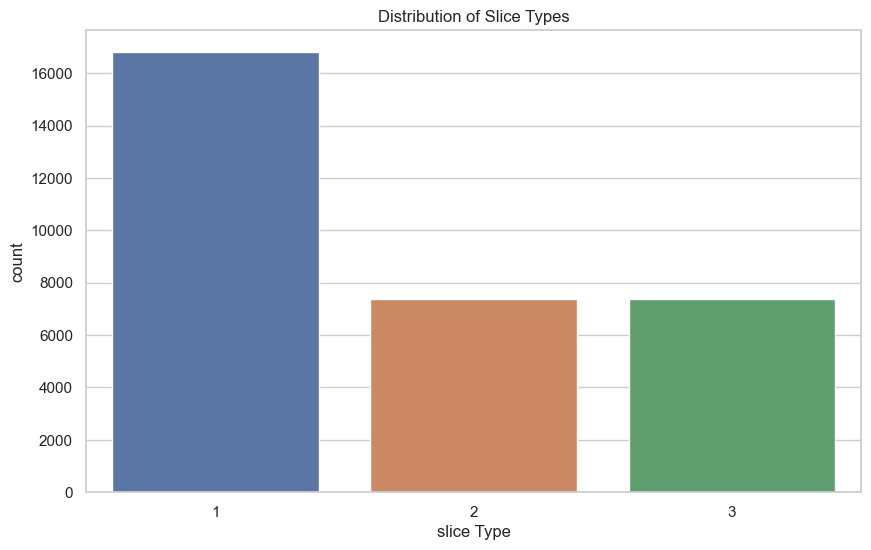

In [36]:
sns.countplot(x="slice Type", data=train_df)
plt.title("Distribution of Slice Types")
plt.show()


# STEP 5 — Descriptive Statistics

In [37]:
train_df.describe()


,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone,slice Type
count,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000
mean,10.974923,11.476459,0.003079,114.126745,0.468100,0.531900,0.441187,0.558813,0.106291,0.057943,0.116107,0.057879,0.059716,0.117722,0.058734,0.425609,1.702150
std,6.053641,6.915643,0.004344,106.320976,0.498989,0.498989,0.496537,0.496537,0.308215,0.233639,0.320358,0.233519,0.236963,0.322283,0.235130,0.494443,0.822956
min,1.000000,0.000000,0.000001,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,6.000000,6.000000,0.000001,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,11.000000,11.000000,0.001000,75.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,16.000000,17.000000,0.010000,150.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
max,22.000000,23.000000,0.010000,300.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


# STEP 6 — Missing Values Check

In [38]:
train_df.isnull().sum()


    LTE/5g Category     0
Time                    0
Packet Loss Rate        0
Packet delay            0
IoT                     0
LTE/5G                  0
GBR                     0
Non-GBR                 0
AR/VR/Gaming            0
Healthcare              0
Industry 4.0            0
IoT Devices             0
Public Safety           0
Smart City & Home       0
Smart Transportation    0
Smartphone              0
slice Type              0
dtype: int64

In [39]:
test_df.isnull().sum()

LTE/5g Category         0
Time                    0
Packet Loss Rate        0
Packet delay            0
IoT                     0
LTE/5G                  0
GBR                     0
Non-GBR                 0
AR/VR/Gaming            0
Healthcare              0
Industry 4.0            0
IoT Devices             0
Public Safety           0
Smart City & Home       0
Smart Transportation    0
Smartphone              0
dtype: int64

# STEP 7 — Duplicate Rows

In [40]:
train_df.duplicated().sum()


22625

In [41]:
train_df = train_df.drop_duplicates()

# STEP 8 — Feature Distributions (Univariate Analysis)

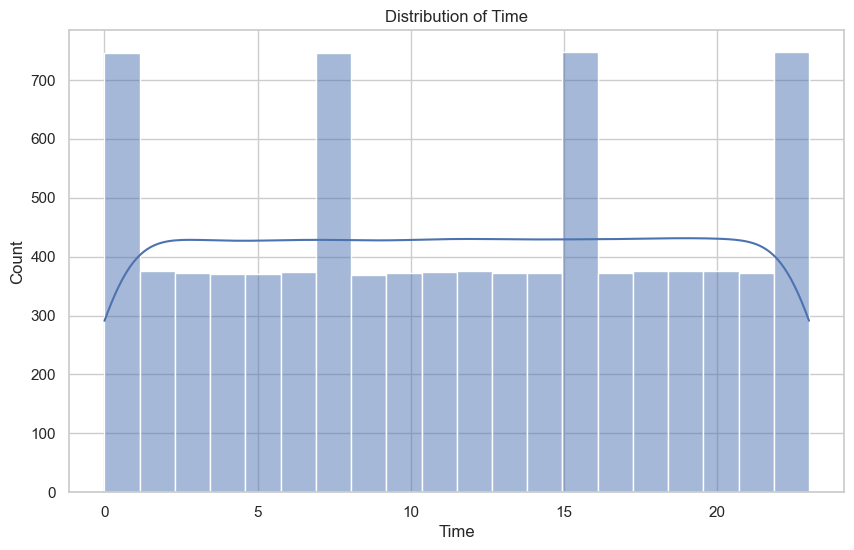

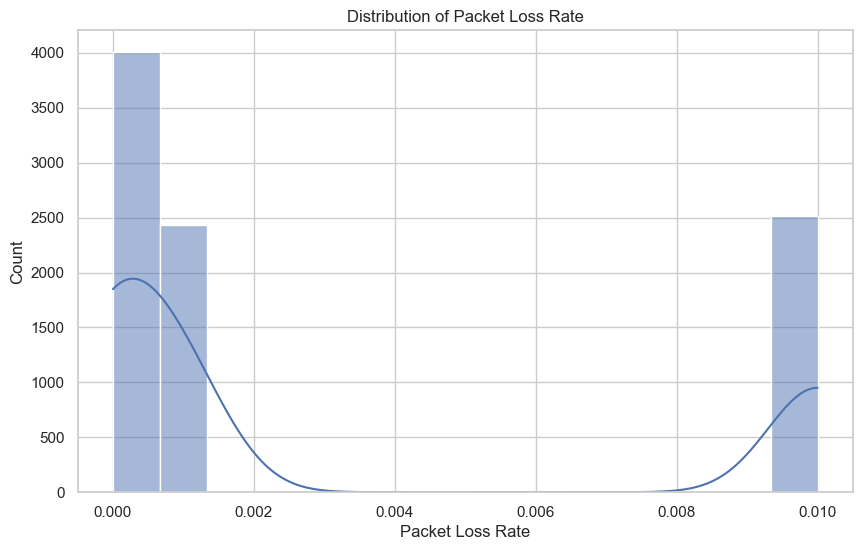

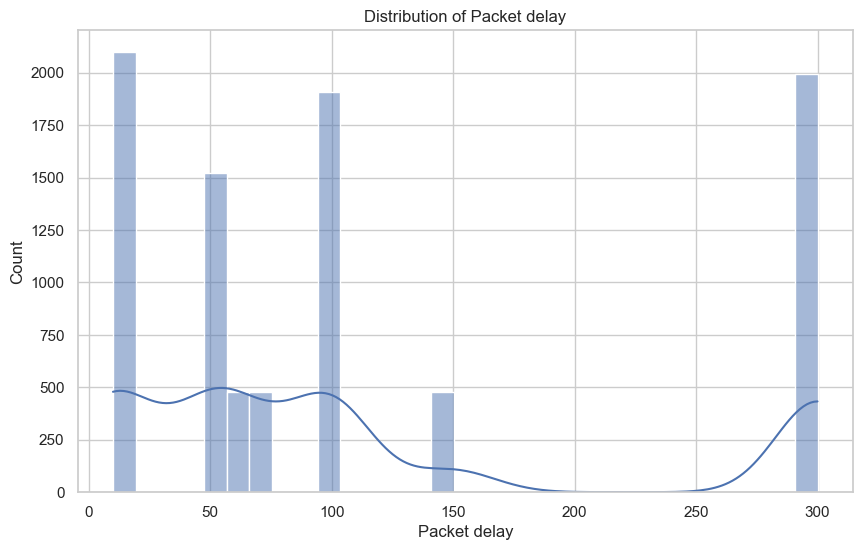

KeyError: 'LTE/5g Category'

In [42]:
numerical_features = [
    "Time", "Packet Loss Rate", "Packet delay", "LTE/5g Category"
]

for col in numerical_features:
    sns.histplot(train_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


# STEP 9 — Binary & Categorical Features

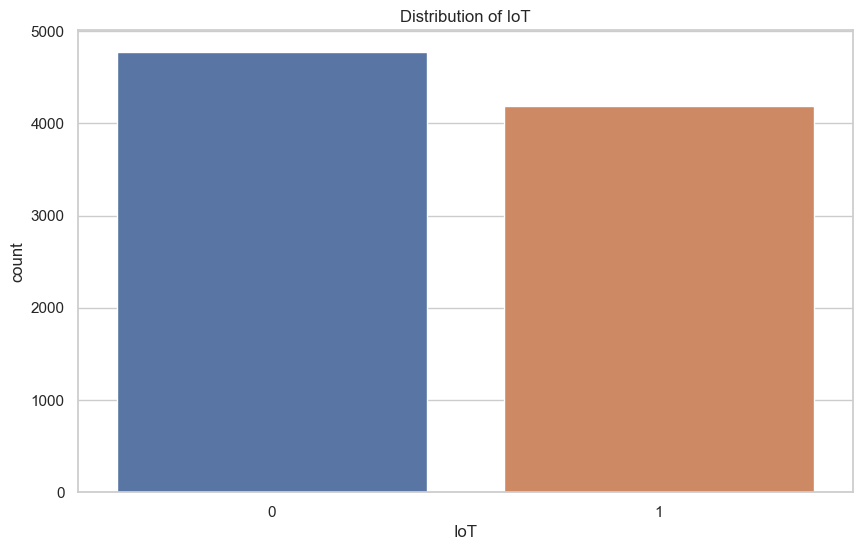

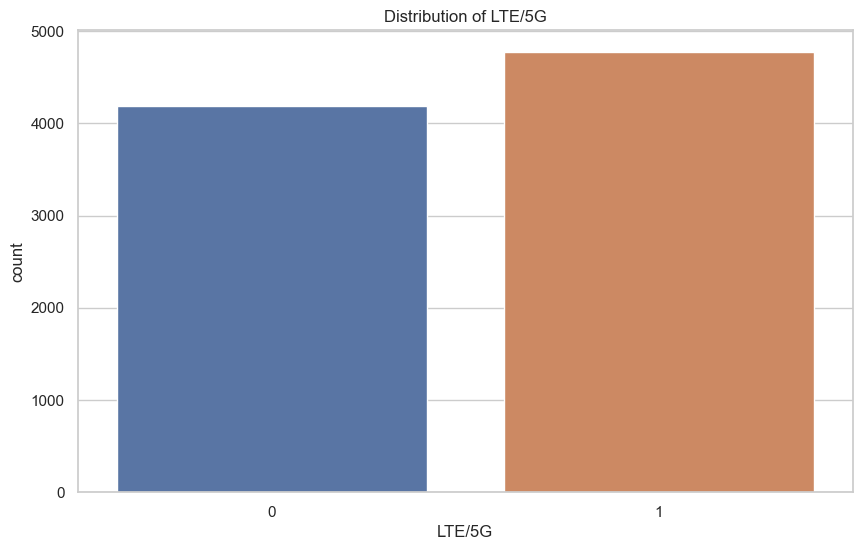

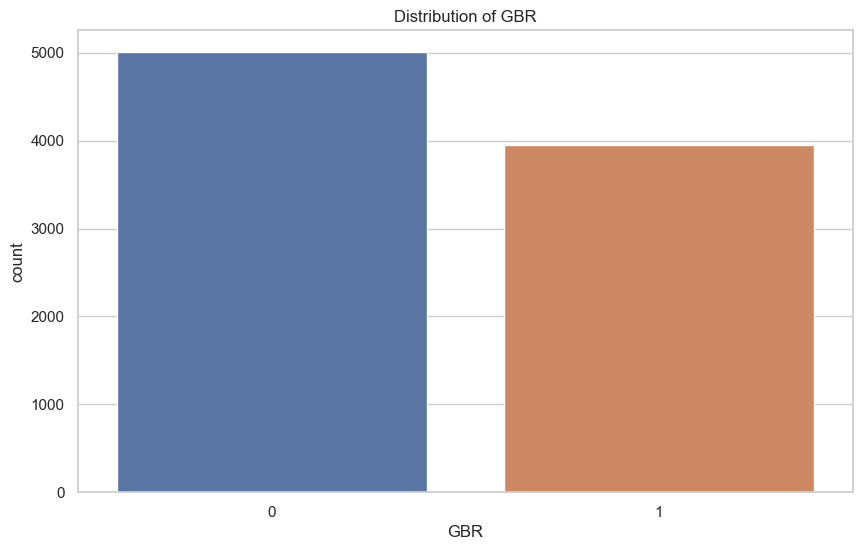

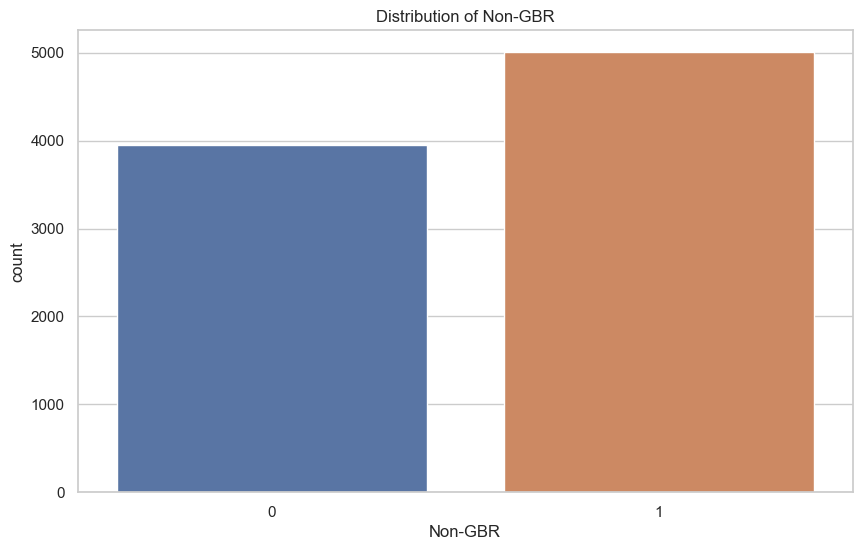

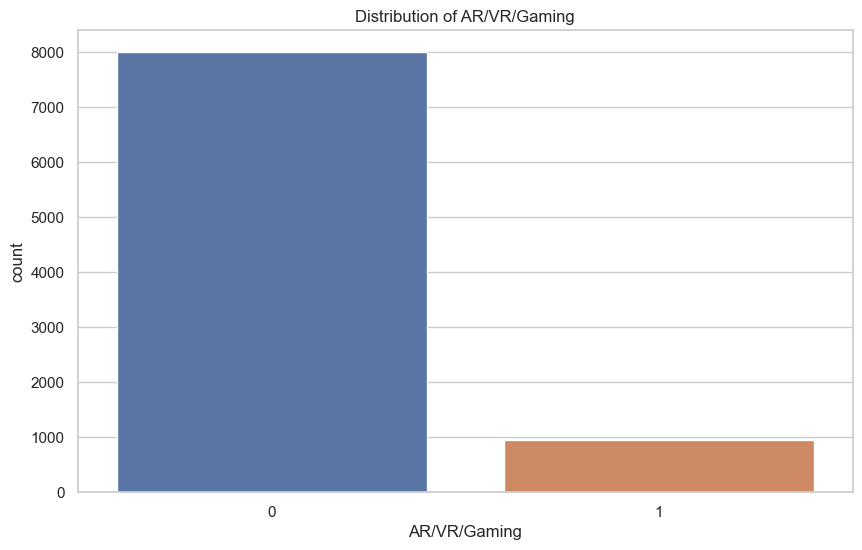

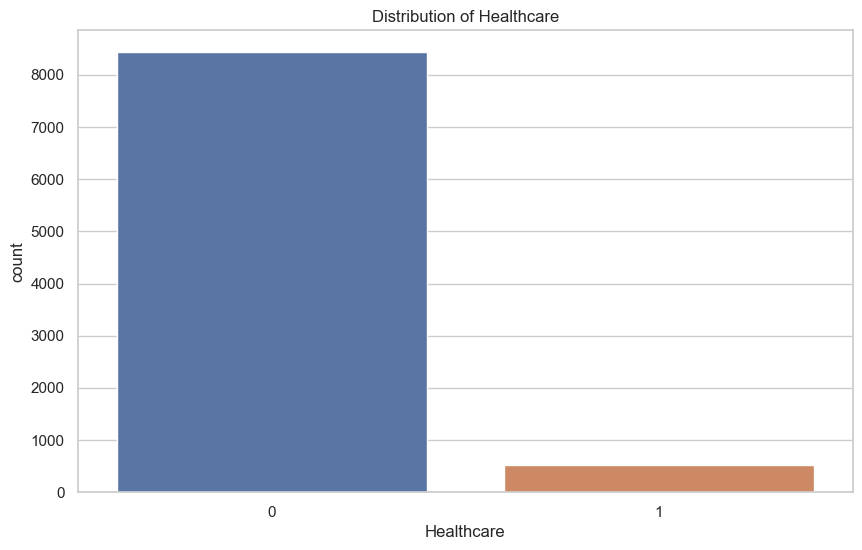

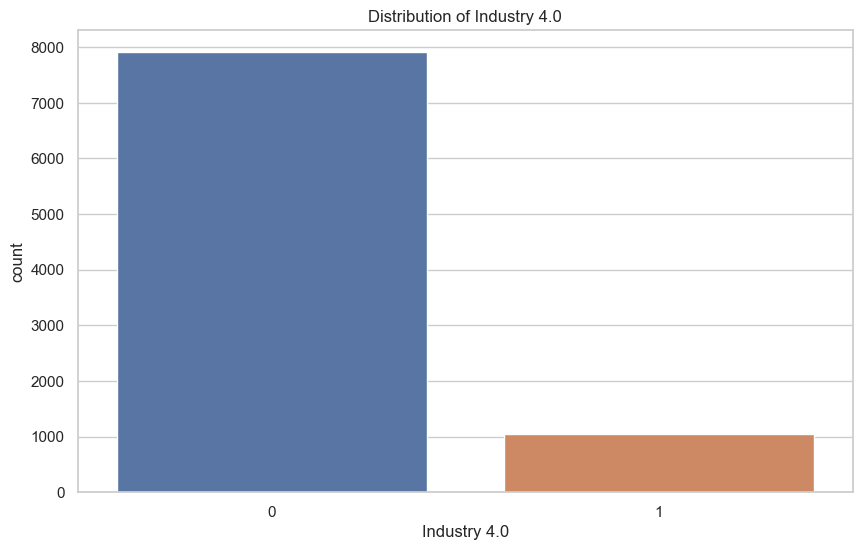

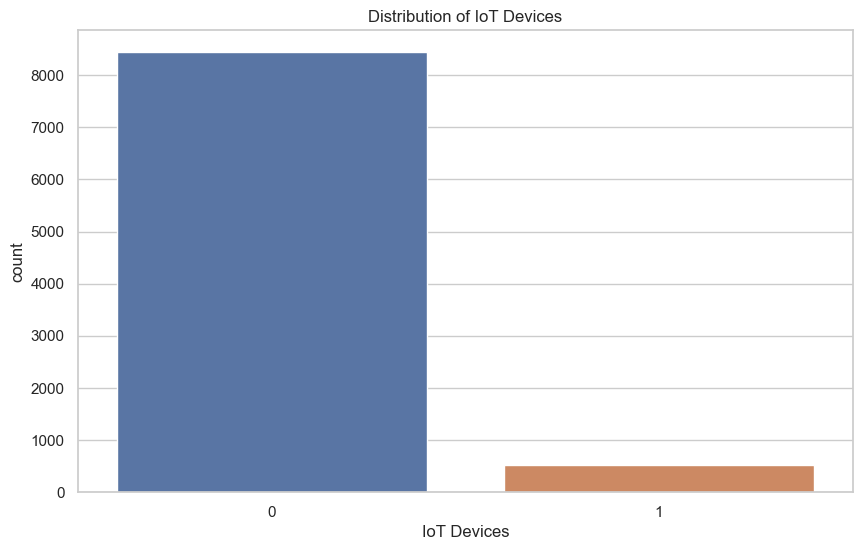

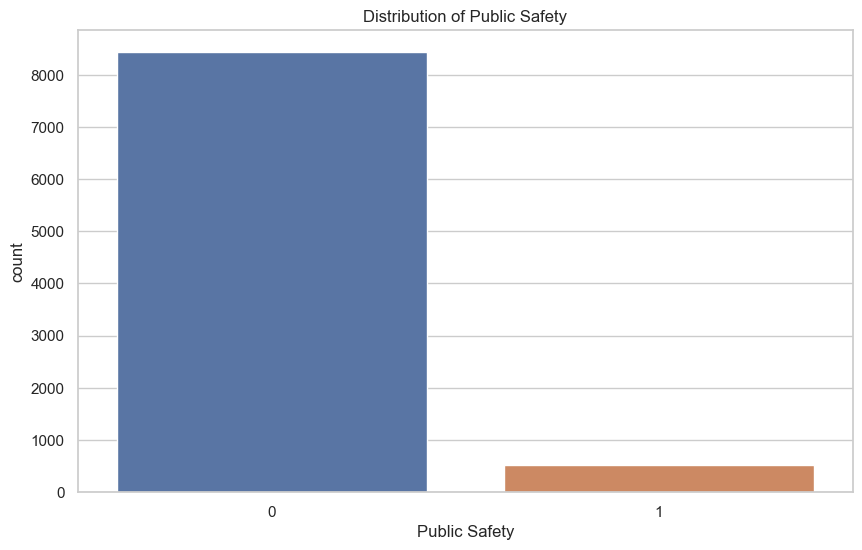

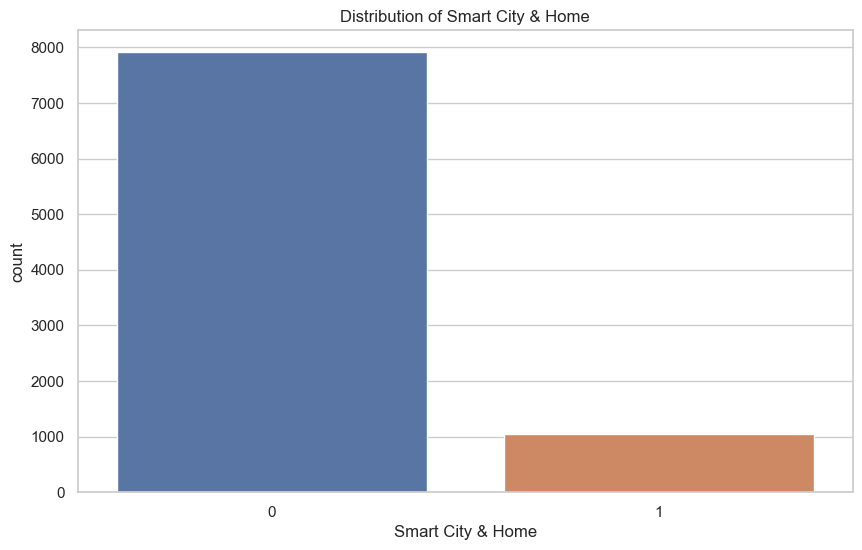

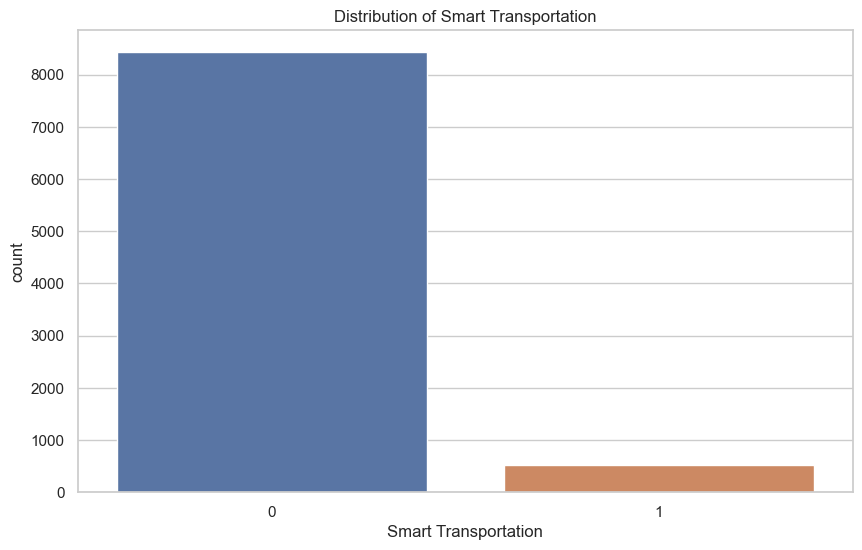

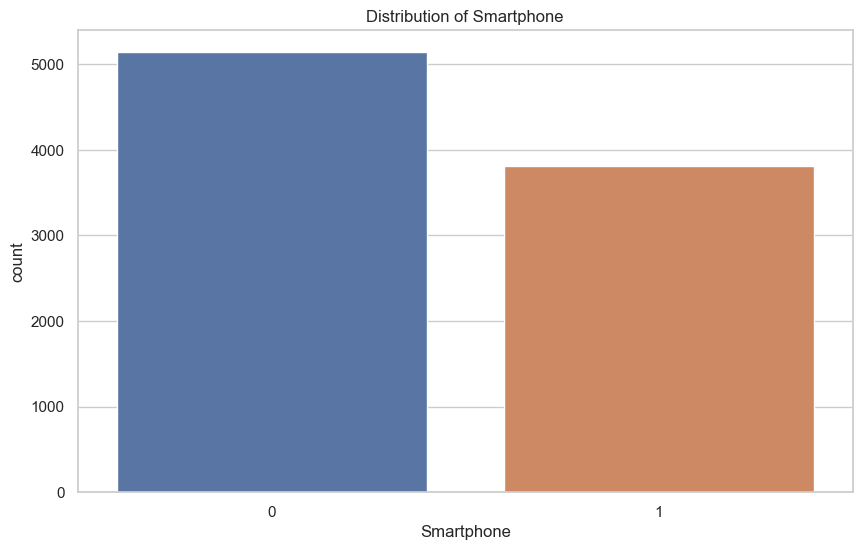

In [ ]:
binary_features = train_df.columns.drop(
    ["slice Type", "Time", "Packet Loss Rate", "Packet delay", "LTE/5g Category"]
)

for col in binary_features:
    sns.countplot(x=col, data=train_df)
    plt.title(f"Distribution of {col}")
    plt.show()


# STEP 10 — Correlation Analysis

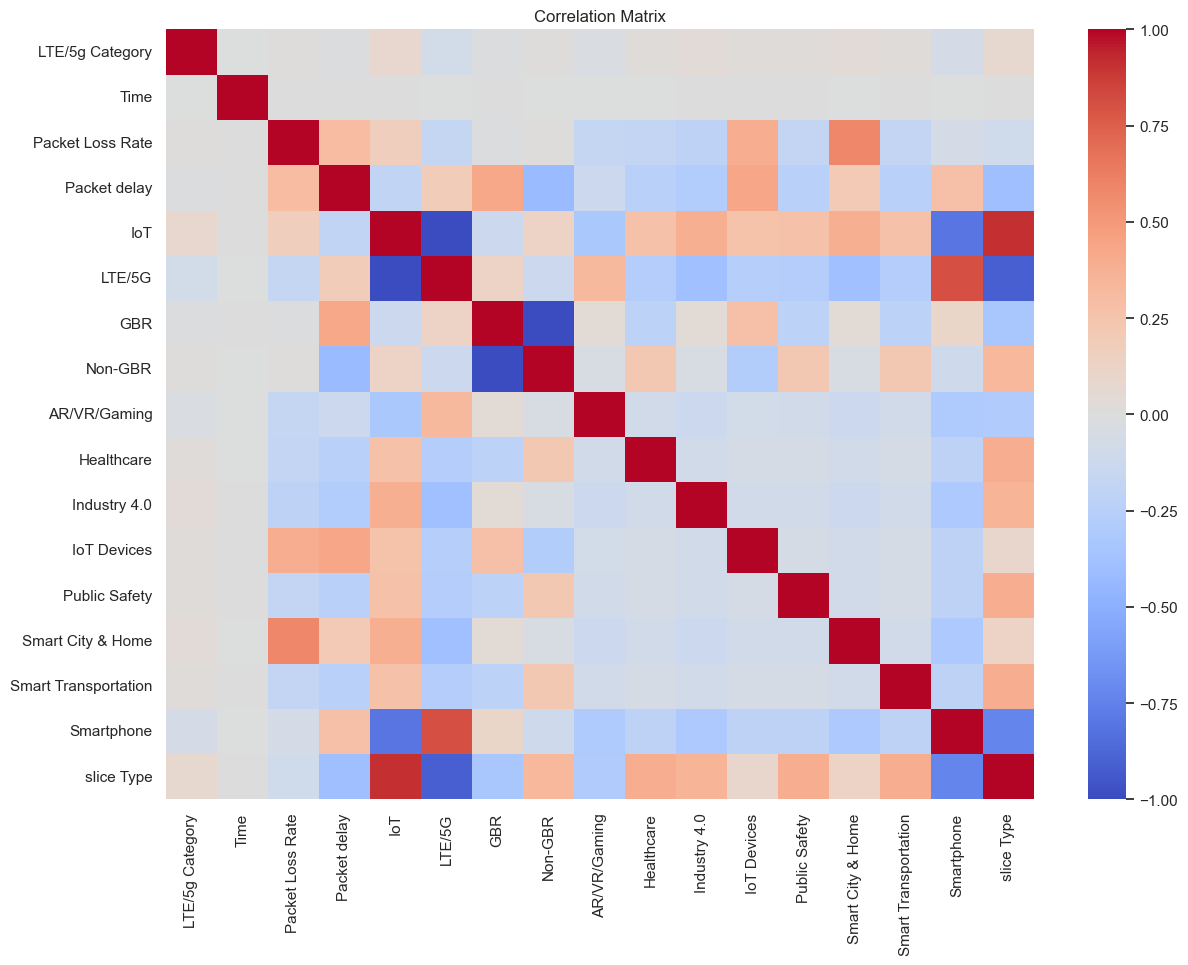

In [ ]:
corr_matrix = train_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()


# STEP 11 — Feature vs Target Analysis

# Packet Delay vs Slice Type

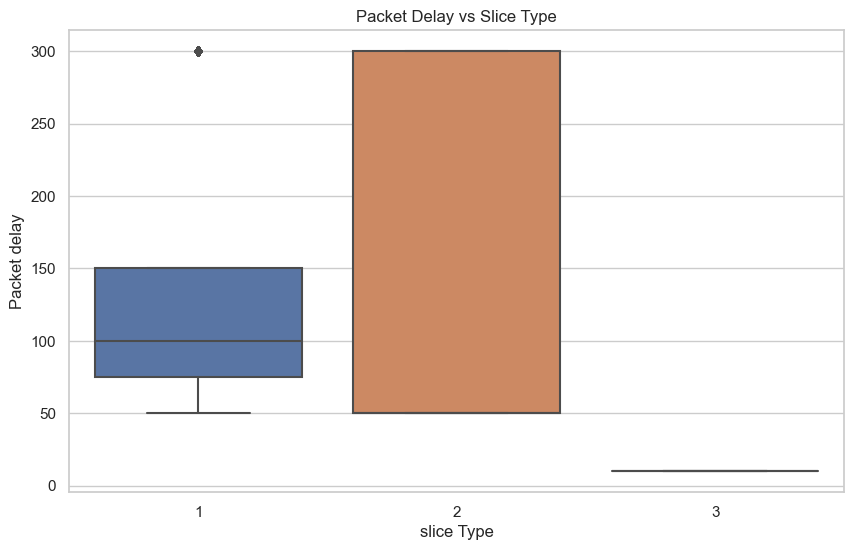

In [ ]:
sns.boxplot(x="slice Type", y="Packet delay", data=train_df)
plt.title("Packet Delay vs Slice Type")
plt.show()


# Packet Loss Rate vs Slice Type

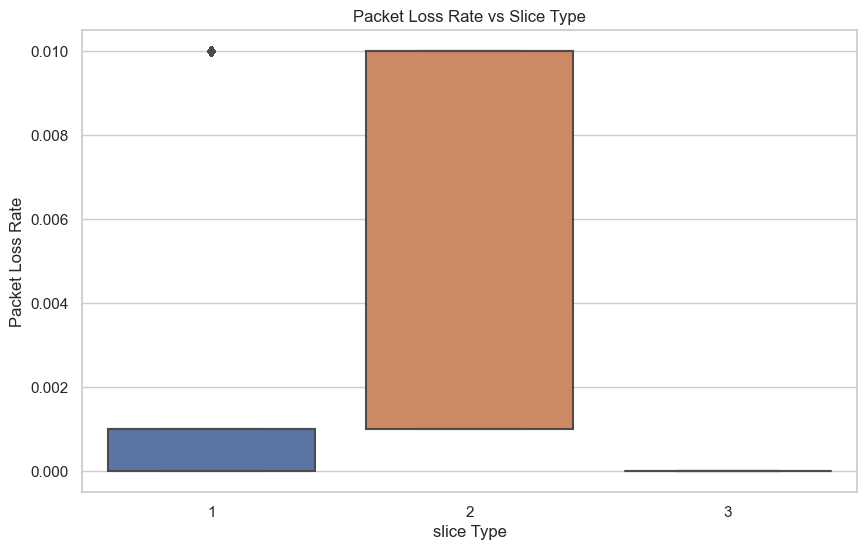

In [ ]:
sns.boxplot(x="slice Type", y="Packet Loss Rate", data=train_df)
plt.title("Packet Loss Rate vs Slice Type")
plt.show()


# STEP 12 — Train vs Test Comparison

In [ ]:
train_df.describe().loc[["mean", "std"]] - test_df.describe().loc[["mean", "std"]]


,AR/VR/Gaming,GBR,Healthcare,Industry 4.0,IoT,IoT Devices,LTE/5G,LTE/5g Category,Non-GBR,Packet Loss Rate,Packet delay,Public Safety,Smart City & Home,Smart Transportation,Smartphone,Time,slice Type
mean,0.000242,-0.000524,-0.000585,-0.001061,-0.000793,-0.001207,0.000793,0.009301,0.000524,-0.000019,-0.307870,0.001188,0.000331,0.000541,0.000551,-0.014081,NaN
std,0.000321,-0.000042,-0.001089,-0.001248,-0.000031,-0.002260,-0.000031,-0.012650,-0.000042,-0.000008,-0.086403,0.002258,0.000408,0.001027,0.000103,-0.004200,NaN


# STEP 13 — Outlier Detection

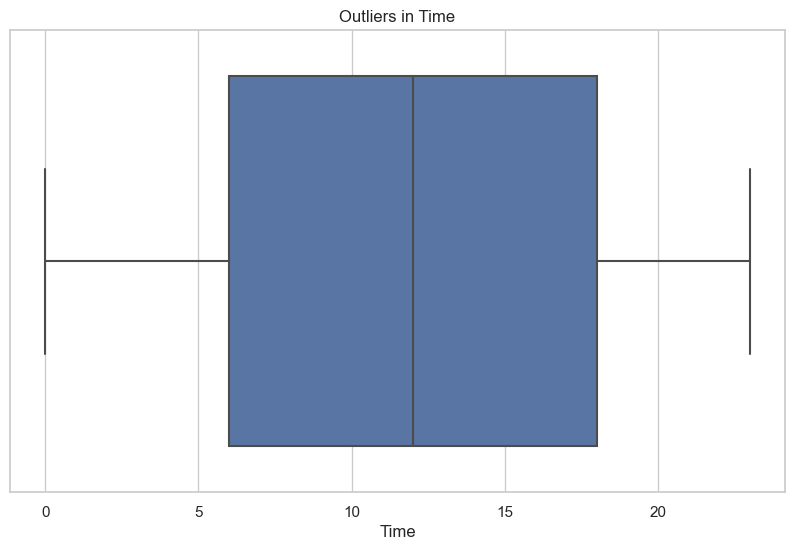

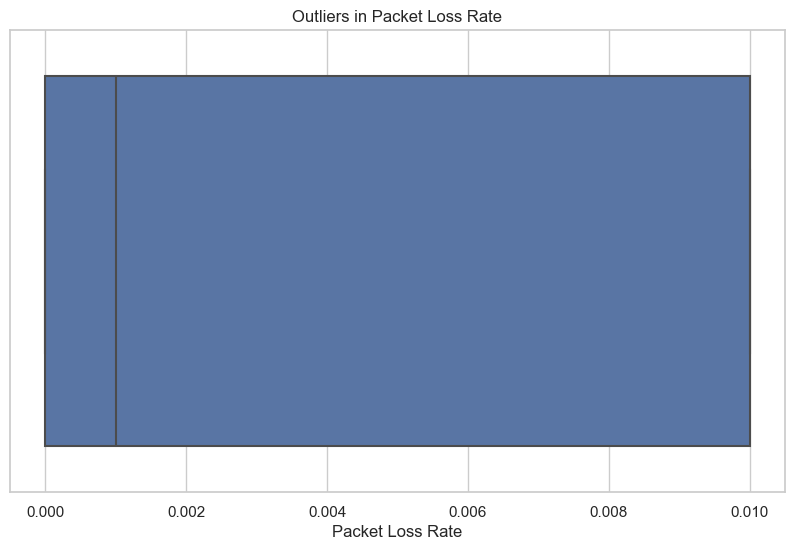

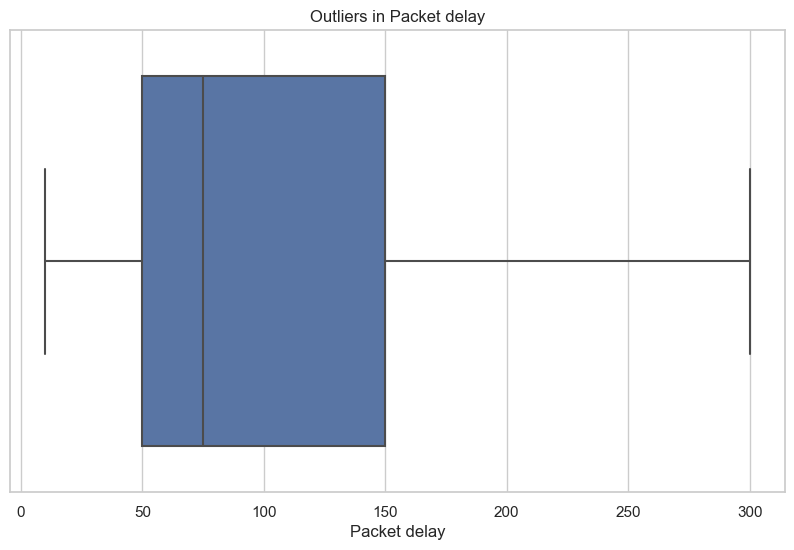

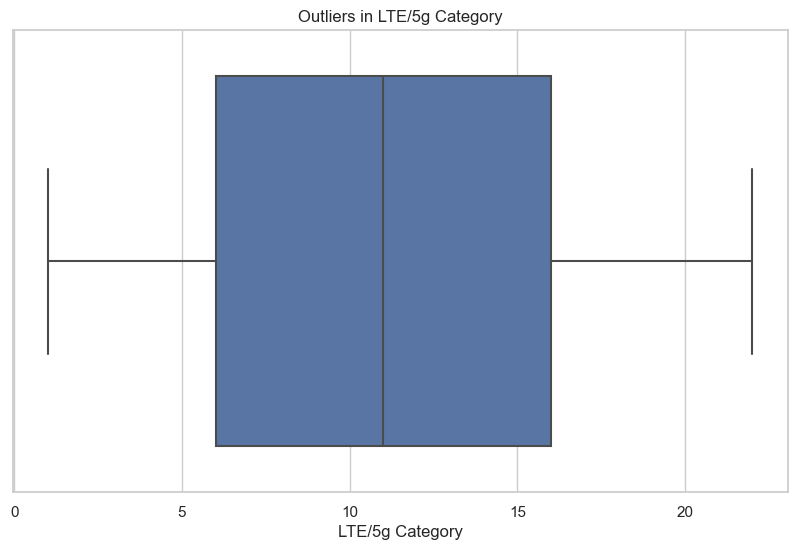

In [ ]:
for col in numerical_features:
    sns.boxplot(x=train_df[col])
    plt.title(f"Outliers in {col}")
    plt.show()


In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("/", "_")
    )
    return df

train_df = clean_columns(train_df)
test_df  = clean_columns(test_df)

print(train_df.columns)
print(test_df.columns)

Index(['packet_loss_rate', 'packet_delay', 'lte_5g_category', 'gbr',
       'non-gbr'],
      dtype='object')
Index(['packet_loss_rate', 'packet_delay', 'lte_5g_category', 'gbr',
       'non-gbr'],
      dtype='object')


In [54]:
features = [
    'packet_loss_rate',
    'packet_delay',
    'lte_5g_category',
    'gbr',
    'non-gbr',   # ⚠️ vérifier ce nom après print
    'slice_type'
]

# correction automatique
features = [col for col in features if col in train_df.columns and col in test_df.columns]

print("Features finales:", features)

train_df = train_df[features]
test_df  = test_df[features]

Features finales: ['packet_loss_rate', 'packet_delay', 'lte_5g_category', 'gbr', 'non-gbr']


In [57]:
for col in categorical_cols:
    train_df[col] = train_df[col].astype(str)
    test_df[col]  = test_df[col].astype(str)
    
    le = LabelEncoder()
    le.fit(list(train_df[col]) + list(test_df[col]))
    
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

In [58]:
def compute_qos(row):
    loss = row['packet_loss_rate']
    delay = row['packet_delay']
    
    # modèle simple basé sur perte + latence
    score = np.exp(-(loss + delay/100))
    
    return min(max(score, 0), 1)

train_df['qos_probability'] = train_df.apply(compute_qos, axis=1)
test_df['qos_probability']  = test_df.apply(compute_qos, axis=1)

In [59]:
X_train = train_df.drop('qos_probability', axis=1)
y_train = train_df['qos_probability']

X_test  = test_df.drop('qos_probability', axis=1)
y_test  = test_df['qos_probability']

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "y_pred": y_pred,
        "model": model
    }

In [62]:
results_df = pd.DataFrame(results).T[['MAE', 'RMSE', 'R2']]
results_df

,MAE,RMSE,R2
Linear Regression,0.094148,0.106893,0.876773
Random Forest,0.0,0.0,1.0
Gradient Boosting,0.000013,0.000016,1.0


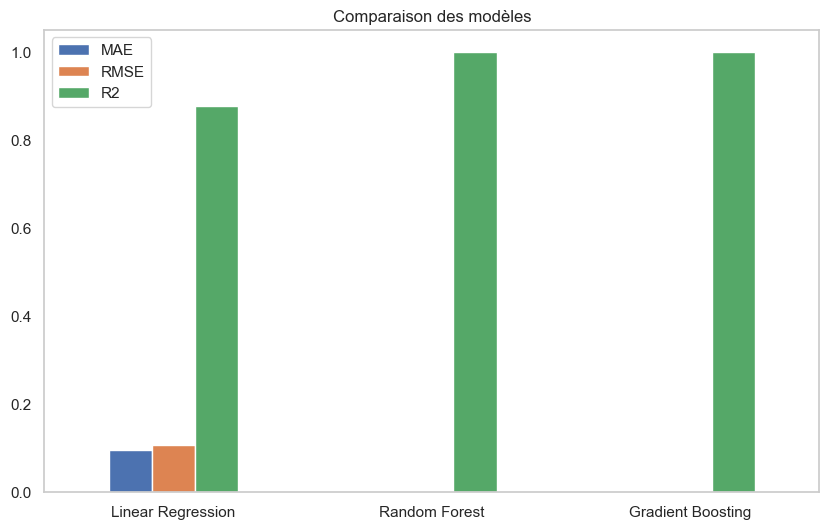

In [63]:
results_df.plot(kind='bar')
plt.title("Comparaison des modèles")
plt.xticks(rotation=0)
plt.grid()
plt.show()

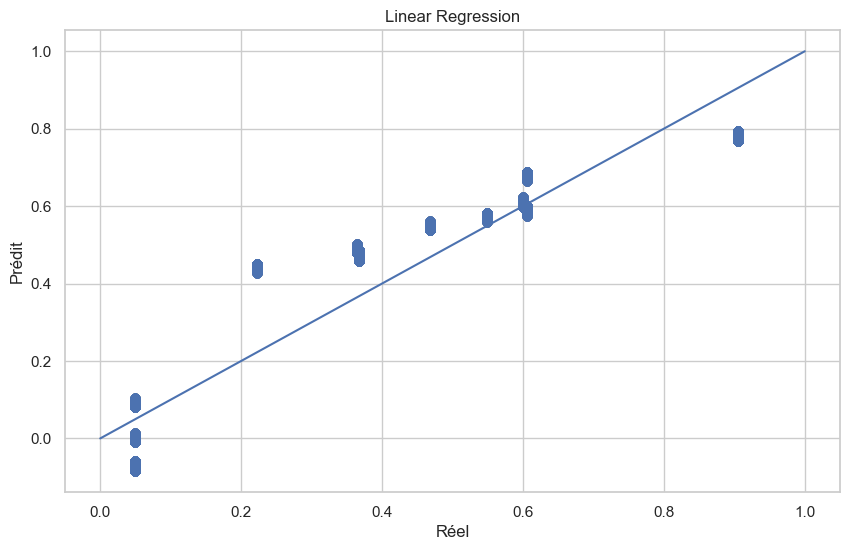

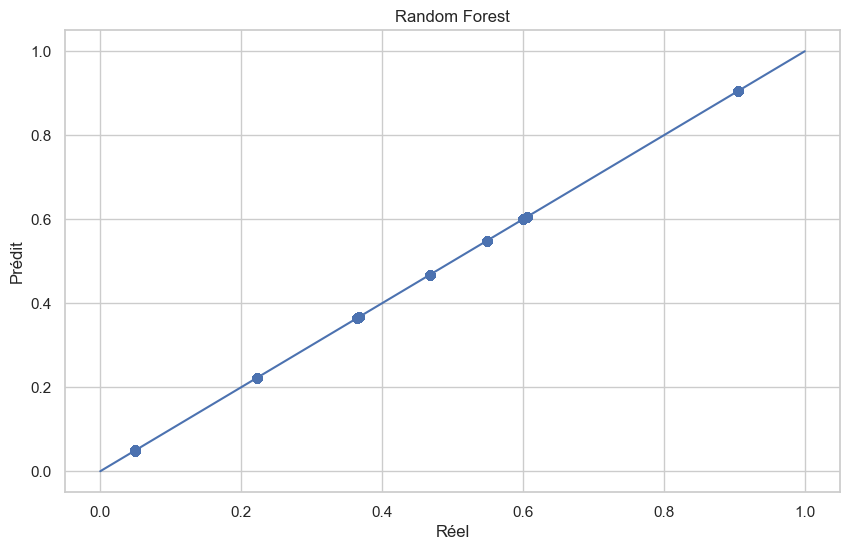

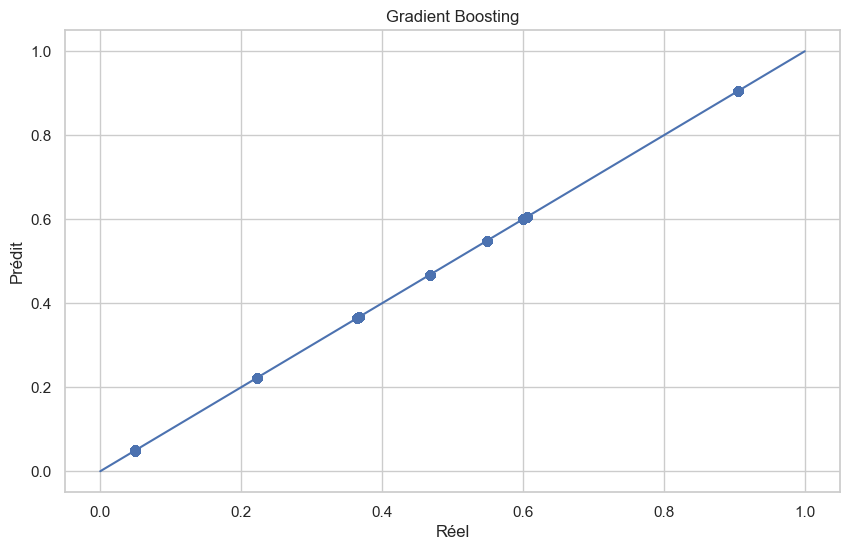

In [64]:
for name in results:
    plt.figure()
    plt.scatter(y_test, results[name]['y_pred'])
    plt.title(name)
    plt.xlabel("Réel")
    plt.ylabel("Prédit")
    plt.plot([0,1],[0,1])
    plt.show()

Colonnes disponibles : Index(['lte_5g_category', 'time', 'packet_loss_rate', 'packet_delay', 'iot',
       'lte_5g', 'gbr', 'non-gbr', 'ar_vr_gaming', 'healthcare',
       'industry_4.0', 'iot_devices', 'public_safety', 'smart_city_&_home',
       'smart_transportation', 'smartphone', 'slice_type'],
      dtype='object')
   qos_probability
0         0.904837
1         0.404263
2         0.049787
3         0.364219
4         0.600496

Statistiques QoS:
count    31583.000000
mean         0.483463
std          0.304182
min          0.049787
25%          0.222907
50%          0.467666
75%          0.666517
max          0.904837
Name: qos_probability, dtype: float64


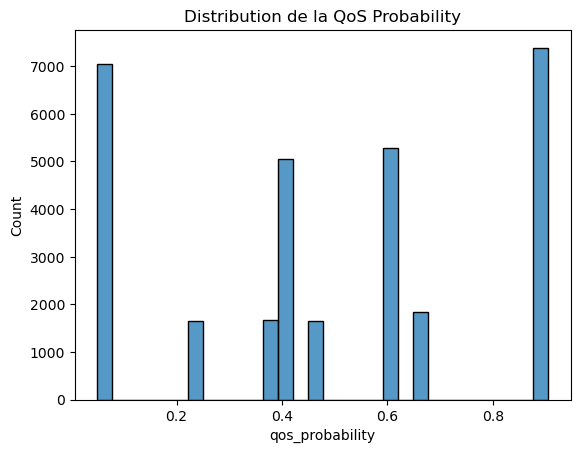

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 🔴 1. Charger les données (OBLIGATOIRE)
train_df = pd.read_csv("train_dataset.csv")
test_df  = pd.read_csv("test_dataset.csv")

# 🔴 2. Nettoyer les colonnes
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("/", "_")
    )
    return df

train_df = clean_columns(train_df)
test_df  = clean_columns(test_df)

# 🔴 3. Vérification colonnes
print("Colonnes disponibles :", train_df.columns)


# 🔴 4. Fonction QoS
def compute_qos(row):
    loss = row['packet_loss_rate']
    delay = row['packet_delay']
    gbr = row['gbr']
    
    score = np.exp(-(loss + delay/100)) * (1 + gbr * 0.1)
    
    return min(max(score, 0), 1)


# 🔴 5. Application
train_df['qos_probability'] = train_df.apply(compute_qos, axis=1)
test_df['qos_probability']  = test_df.apply(compute_qos, axis=1)


# 🔴 6. Affichage
print(train_df[['qos_probability']].head())


# 🔴 7. Statistiques
print("\nStatistiques QoS:")
print(train_df['qos_probability'].describe())


# 🔴 8. Visualisation
sns.histplot(train_df['qos_probability'], bins=30)
plt.title("Distribution de la QoS Probability")
plt.show()